# Shape-constrained fits: monotone, convex and bounded curves from noisy data

Physics often says what shape a fitted curve must have, even when the measurements do not:

- a battery's open-circuit voltage rises with its state of charge;
- a generator's fuel cost is convex in its load, or economic dispatch loses its convexity;
- an efficiency lies between 0 and 1.

Least squares on noisy data honours none of this, and interpolants like PCHIP that preserve the
data's shape preserve the noise's shape too. `interp.constrained` fits a B-spline by least squares
under linear constraints on its coefficients that make the shape hold everywhere, not only at the
data. The fit is a quadratic program solved by PIQP when the graph is built.

| Scaly feature | Where |
| --- | --- |
| `interp.constrained(..., monotone=, bounds=)` | the battery |
| the fit's KKT conditions, checked from outside | the battery |
| `BSpline.inverse` in generated code | state of charge from voltage |
| `interp.constrained(..., convex=)`, against `trust-constr` | the fuel cost |
| a bounded 2-D fit | the efficiency map |

CasADi has no counterpart. The references are SciPy's `trust-constr` on the same problem, and
the optimality conditions themselves.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import BSpline as SciBSpline
from scipy.optimize import LinearConstraint, minimize

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
from scaly import interp

plotstyle.use()
rng = np.random.default_rng(1)


def unit_rows(f, transform):
  """The matrix of a linear map of the coefficients, one unit coefficient vector at a time."""
  n = np.size(f.coeffs)
  return np.column_stack([transform(interp.BSpline(f.knots, np.eye(n)[i].reshape(np.shape(f.coeffs)), f.degree)) for i in range(n)])

## A battery's open-circuit voltage

The cell is an LFP (lithium iron phosphate) cell. Its voltage climbs steeply from empty, then
crosses a plateau that rises only 0.13 V between 10 % and 90 % charge, then climbs again near
full. 120 measurements with 10 mV of noise: almost half of the consecutive pairs decrease.

The monotone fit constrains the coefficients of the spline's derivative, itself a B-spline, to be
non-negative. That is sufficient for $f' \ge 0$ everywhere, by the convex-hull property. The
bounds apply to the coefficients, so they hold for the whole curve. The same knots
(24 intervals) without constraints give plain least squares, and PCHIP and Steffen interpolate
the raw measurements.

In [2]:
cell_rng = np.random.default_rng(2)
soc = np.sort(cell_rng.uniform(0.0, 1.0, 120))
ocv_true = lambda s: 3.0 + 0.3 * np.tanh(15 * s) + 0.12 * s + 0.15 * np.exp(30 * (s - 1))  # an LFP cell's plateau
ocv = ocv_true(soc) + 0.01 * cell_rng.normal(size=soc.size)
print(f"{np.sum(np.diff(ocv) < 0)} of {soc.size - 1} consecutive pairs of measurements decrease")

started = time.perf_counter()
monotone = interp.constrained(soc, ocv, knots=24, monotone="increasing", bounds=(2.5, 3.65))
first_fit_s = time.perf_counter() - started
started = time.perf_counter()
interp.constrained(soc, ocv, knots=24, monotone="increasing", bounds=(2.5, 3.65))
later_fit_ms = 1e3 * (time.perf_counter() - started)
plain = interp.constrained(soc, ocv, knots=24)  # no constraint: least squares on the same knots
fits = {
  "least squares, 24 intervals": plain,
  "monotone and bounded": monotone,
  "PCHIP through the data": interp.interpolant(soc, ocv, kind="pchip"),
  "Steffen through the data": interp.interpolant(soc, ocv, kind="steffen"),
}
dense = np.linspace(soc[0], soc[-1], 10_000)
ocv_rows = []
curves, truth_error = {}, {}
for label, f in fits.items():
  s = f.to_scipy()
  curves[label] = (s(dense), s.derivative()(dense))
  rms = np.sqrt(np.mean((s(soc) - ocv) ** 2))
  ocv_rows.append((label, rms, curves[label][1].min(), np.sum(np.diff(np.sign(curves[label][1])) != 0)))
  truth_error[label] = np.sqrt(np.mean((curves[label][0] - ocv_true(dense)) ** 2))
  print(f"{label:28s} rms to the data {1e3 * rms:5.2f} mV, to the truth {1e3 * truth_error[label]:5.2f} mV; min dOCV/dSOC {curves[label][1].min():+8.2f} V")
print(f"the constrained fit: {first_fit_s:.2f} s at its first call (it generates and compiles a PIQP solver for its size unless one is cached), {later_fit_ms:.1f} ms after")

57 of 119 consecutive pairs of measurements decrease


least squares, 24 intervals  rms to the data  9.23 mV, to the truth  5.05 mV; min dOCV/dSOC    -0.36 V
monotone and bounded         rms to the data  9.51 mV, to the truth  3.29 mV; min dOCV/dSOC    +0.02 V
PCHIP through the data       rms to the data  0.00 mV, to the truth  9.85 mV; min dOCV/dSOC   -28.11 V
Steffen through the data     rms to the data  0.00 mV, to the truth  9.88 mV; min dOCV/dSOC   -28.11 V
the constrained fit: 0.06 s at its first call (it generates and compiles a PIQP solver for its size unless one is cached), 1.5 ms after


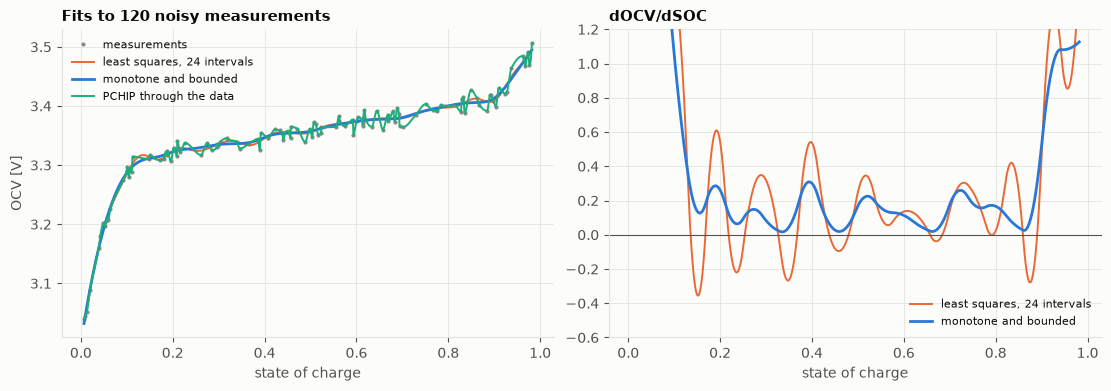

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(soc, ocv, ".", color=plotstyle.NEUTRAL, ms=4, label="measurements")
for (label, (value, _)), color in zip(curves.items(), (plotstyle.ORANGE, plotstyle.BLUE, plotstyle.AQUA, plotstyle.MAGENTA), strict=True):
  if not label.startswith("Steffen"):
    ax1.plot(dense, value, color=color, lw=1.4 if label != "monotone and bounded" else 2.0, label=label)
ax1.set_xlabel("state of charge")
ax1.set_ylabel("OCV [V]")
ax1.set_title("Fits to 120 noisy measurements")
ax1.legend(fontsize=8)
for (label, (_, slope)), color in zip(curves.items(), (plotstyle.ORANGE, plotstyle.BLUE, plotstyle.AQUA, plotstyle.MAGENTA), strict=True):
  if not label.startswith(("PCHIP", "Steffen")):
    ax2.plot(dense, slope, color=color, lw=1.4 if label != "monotone and bounded" else 2.0, label=label)
ax2.axhline(0.0, color=plotstyle.TEXT_SECONDARY, lw=0.8)
ax2.set_ylim(-0.6, 1.2)
ax2.set_xlabel("state of charge")
ax2.set_title("dOCV/dSOC")
ax2.legend(fontsize=8)
plt.show()

Unconstrained, the fit's slope turns negative on the plateau, down to −0.36 V per unit of charge,
where the noise outweighs the true slope. The interpolants through the raw data follow the noise
itself, with slopes down to −28. PCHIP and Steffen preserve the data's shape, and here that shape
is noise.

The monotone fit's slope never falls below zero. It is also closer to the true curve: 3.3 mV rms
against 5.1 mV, since the constraint removes wiggles the noise put in. It pays for that with
0.3 mV more residual on the data. The first call at a problem size may generate and compile a
solver; a later fit takes about a millisecond.

The solver's answer can be checked without the solver. At the fit, the gradient of the least-
squares objective must be balanced by the active constraints' normals with non-negative
multipliers, and every constraint must hold:

In [4]:
# The KKT conditions of the monotone, bounded fit, checked from outside the solver: the objective's
# gradient, the constraints active at the solution, and multipliers that balance the two.
c = np.asarray(monotone.coeffs)
design = monotone.basis(soc).toarray()
gradient = 2 * design.T @ (design @ c - ocv)
slopes = unit_rows(monotone, lambda b: np.asarray(b.derivative().coeffs))  # the derivative's coefficients, D c
rows = np.vstack([slopes, np.eye(c.size), -np.eye(c.size)])
values = np.concatenate([slopes @ c, c - 2.5, 3.65 - c])  # each >= 0
active = values <= 1e-10
multipliers, *_ = np.linalg.lstsq(rows[active].T, gradient, rcond=None)
stationarity = np.abs(gradient - rows[active].T @ multipliers).max() / np.abs(gradient).max()
print(f"{active.sum()} active constraints ({np.sum(active[: slopes.shape[0]])} slopes, {np.sum(active[slopes.shape[0]:])} bounds)")
print(f"feasibility: min slope coefficient {values[: slopes.shape[0]].min():.1e}, min bound margin {values[slopes.shape[0]:].min():.1e}")
print(f"stationarity {stationarity:.1e} (relative); multipliers >= {multipliers.min():.2e}")

6 active constraints (6 slopes, 0 bounds)
feasibility: min slope coefficient -4.3e-14, min bound margin 1.6e-01
stationarity 6.5e-12 (relative); multipliers >= 1.61e-04


In [5]:
import scaly as sc

soc_of_ocv = monotone.inverse()
volts = np.linspace(3.05, 3.55, 11)


@sc.function(sc.L("v", volts.shape), output=sc.G("soc", "ocv_again"), name="soc_from_ocv")
def soc_from_ocv(v):
  x = soc_of_ocv(v)
  return x, monotone(x)


read_back, ocv_again = soc_from_ocv(volts)
soc_round_trip = float(np.abs(ocv_again - volts).max())
try:
  plain.inverse()
  refused = False
except ValueError as error:
  refused = True
  print(f"the unconstrained fit's inverse is refused: {error}")
print("OCV [V]: " + " ".join(f"{v:5.2f}" for v in volts))
print("SOC:     " + " ".join(f"{x:5.3f}" for x in read_back))
print(f"OCV(SOC(v)) = v to {soc_round_trip:.1e} V")

the unconstrained fit's inverse is refused: inverse() needs a strictly monotone spline; its values at the knots are not
OCV [V]:  3.05  3.10  3.15  3.20  3.25  3.30  3.35  3.40  3.45  3.50  3.55
SOC:     0.011 0.022 0.036 0.053 0.075 0.116 0.411 0.799 0.941 0.987 1.031
OCV(SOC(v)) = v to 1.8e-15 V


Six slope constraints are active. They hold to $4 \times 10^{-14}$, and the
gradient is balanced by their normals to $4 \times 10^{-12}$ with strictly positive multipliers:
a KKT point, and for this convex problem the optimum. The fit lands on the active constraints
exactly, not a barrier's width inside them, because an active-set step follows the interior-point
solve.

Monotonicity is what makes the curve invertible. A battery management system reads the state of
charge from a rested voltage. The monotone fit's `inverse()` does this in generated code, and
the round trip returns the voltage to $10^{-15}$. The unconstrained fit's inverse is refused.
The table also shows why LFP is hard to estimate: across the plateau, 50 mV spans 30 % of the
charge.

## A convex fuel-cost curve

A generator's fuel cost rises with its output. Measured curves carry valve-point ripples, and
economic dispatch wants a convex cost, whose optimum is global. The convex fit constrains the
coefficients of the second derivative. It is checked against SciPy's `trust-constr` on the same
objective and constraints, a small problem of 11 coefficients.

against trust-constr: 9.7e-09 (47 iterations, 21 ms)
least squares  min second derivative  -67.28; rms to the data 0.0207
convex         min second derivative   -0.00; rms to the data 0.0224


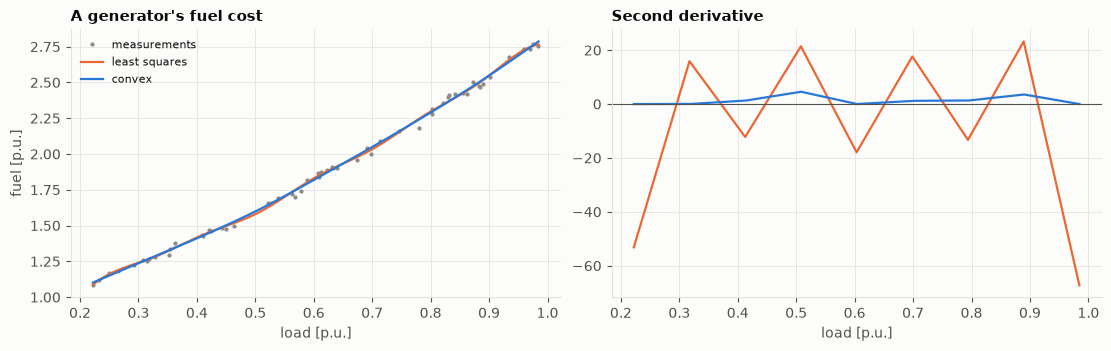

In [6]:
load = np.sort(rng.uniform(0.2, 1.0, 60))
fuel_true = lambda p: 0.8 + 1.1 * p + 0.9 * p**2 + 0.05 * np.abs(np.sin(9 * np.pi * p))  # with valve-point ripples
fuel = fuel_true(load) + 0.02 * rng.normal(size=load.size)
convex = interp.constrained(load, fuel, knots=8, convex="convex")
free = interp.constrained(load, fuel, knots=8)

# The reference: SciPy's trust-constr on the same objective and constraints.
t = convex.knots[0]
B = SciBSpline.design_matrix(load, t, 3).toarray()
curvature = unit_rows(convex, lambda b: np.asarray(b.derivative(2).coeffs))
started = time.perf_counter()
ref = minimize(
  lambda c: np.sum((B @ c - fuel) ** 2),
  np.asarray(free.coeffs),
  jac=lambda c: 2 * B.T @ (B @ c - fuel),
  hess=lambda c: 2 * B.T @ B,
  method="trust-constr",
  constraints=[LinearConstraint(curvature, 0.0, np.inf)],
  options={"gtol": 1e-12, "xtol": 1e-14, "barrier_tol": 1e-14, "maxiter": 5000},
)
trust_ms = 1e3 * (time.perf_counter() - started)
convex_error = np.abs(np.asarray(convex.coeffs) - ref.x).max()
print(f"against trust-constr: {convex_error:.1e} ({ref.nit} iterations, {trust_ms:.0f} ms)")
load_dense = np.linspace(load[0], load[-1], 10_000)
for label, f in (("least squares", free), ("convex", convex)):
  s = f.to_scipy()
  print(f"{label:14s} min second derivative {s.derivative(2)(load_dense).min():+7.2f}; rms to the data {np.sqrt(np.mean((s(load) - fuel) ** 2)):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
ax1.plot(load, fuel, ".", color=plotstyle.NEUTRAL, ms=4, label="measurements")
for f, color, label in ((free, plotstyle.ORANGE, "least squares"), (convex, plotstyle.BLUE, "convex")):
  ax1.plot(load_dense, f.to_scipy()(load_dense), color=color, lw=1.6, label=label)
  ax2.plot(load_dense, f.to_scipy().derivative(2)(load_dense), color=color, lw=1.6, label=label)
ax1.set_xlabel("load [p.u.]")
ax1.set_ylabel("fuel [p.u.]")
ax1.set_title("A generator's fuel cost")
ax1.legend(fontsize=8)
ax2.axhline(0.0, color=plotstyle.TEXT_SECONDARY, lw=0.8)
ax2.set_xlabel("load [p.u.]")
ax2.set_title("Second derivative")
plt.show()

The two solvers agree to $10^{-8}$. `trust-constr` takes 46 iterations and about 20 ms in
Python. The unconstrained fit follows the ripples with a second derivative down to −67. The
convex one smooths them away at the cost of 8 % more residual: the closest convex cost to the
data, which a dispatch problem can use.

## A bounded efficiency map

A motor's efficiency against normalized speed and torque, from 600 noisy measurements: a peak
of 0.96, and a drop at low speed. A 2-D fit on a 6 x 6 grid of intervals, with a light
second-difference penalty, is bounded to $[0, 0.96]$. On the coefficients this again holds for
the whole surface.

least squares          range -0.310 to 1.051; above 0.96 on 1.8 % of the square
bounded to [0, 0.96]   range 0.000 to 0.955; above 0.96 on 0.0 % of the square


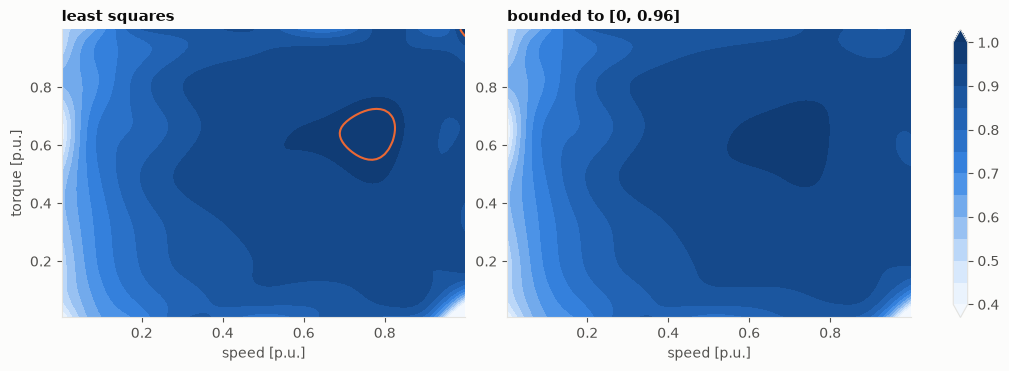

In [7]:
speed, torque = rng.uniform(0.0, 1.0, 600), rng.uniform(0.0, 1.0, 600)
eta_true = lambda w, t: 0.96 - 0.35 * (w - 0.65) ** 2 - 0.3 * (t - 0.55) ** 2 - 0.25 * np.exp(-8 * w)
eta = np.clip(eta_true(speed, torque) + 0.03 * rng.normal(size=600), 0.0, None)
pts = np.column_stack([speed, torque])
free_map = interp.constrained(pts, eta, knots=(6, 6), lam=1e-5)
bounded_map = interp.constrained(pts, eta, knots=(6, 6), bounds=(0.0, 0.96), lam=1e-5)
grids = [np.linspace(pts[:, d].min(), pts[:, d].max(), 101) for d in range(2)]  # the fits' domain: the data's box
G = np.stack(np.meshgrid(*grids, indexing="ij"), axis=-1).reshape(-1, 2)
maps = {label: f.to_scipy()(G).reshape(101, 101) for label, f in (("least squares", free_map), ("bounded to [0, 0.96]", bounded_map))}
for label, m in maps.items():
  print(f"{label:22s} range {m.min():.3f} to {m.max():.3f}; above 0.96 on {100 * np.mean(m > 0.96):.1f} % of the square")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (label, m) in zip(axes, maps.items(), strict=True):
  c = ax.contourf(*grids, m.T, levels=np.linspace(0.4, 1.0, 13), cmap=plotstyle.BLUES, extend="both")
  ax.contour(*grids, m.T, levels=[0.96], colors=plotstyle.ORANGE, linewidths=1.5)
  ax.set_title(label)
  ax.set_xlabel("speed [p.u.]")
fig.colorbar(c, ax=axes)
axes[0].set_ylabel("torque [p.u.]")
plt.show()

Unconstrained, the fit rises to 1.05, an efficiency above one, and falls below zero at a corner
where data are few. Bounded, it stays in $[0, 0.955]$ everywhere in the data's box. The orange
line is the 0.96 contour: present on the left, absent on the right.

## Checks

In [8]:
rows_by = {label: (rms, min_slope, turns) for label, rms, min_slope, turns in ocv_rows}
assert rows_by["monotone and bounded"][1] >= -1e-10 and rows_by["least squares, 24 intervals"][1] < -0.1
assert rows_by["PCHIP through the data"][1] < -1.0 and rows_by["Steffen through the data"][1] < -1.0  # they follow the noise
assert rows_by["monotone and bounded"][0] < 1.05 * rows_by["least squares, 24 intervals"][0]  # the constraint costs little fit
assert truth_error["monotone and bounded"] < truth_error["least squares, 24 intervals"]
assert soc_round_trip < 1e-12 and refused
assert stationarity < 1e-9 and multipliers.min() > -1e-9 and values.min() > -1e-12
assert convex_error < 1e-6 and convex.to_scipy().derivative(2)(load_dense).min() >= -1e-8
assert maps["bounded to [0, 0.96]"].max() <= 0.96 + 1e-9 and maps["bounded to [0, 0.96]"].min() >= -1e-9
assert maps["least squares"].max() > 0.96
print("all 9 checks passed")

all 9 checks passed
